# Spin-echo spiral imaging

A spin echo puts a 180° pulse between the excitation and the readout. The pulse conjugates the
phase accumulated so far, so static field offsets — field inhomogeneity, susceptibility, chemical
shift — unwind themselves and cancel exactly at one instant, the **spin echo**:

$$t_{\mathrm{spin\;echo}} \;=\; t_{90} + 2\,(t_{180} - t_{90})$$

That is $T_2$ weighting instead of $T_2^*$, and it is worth the most to a readout that is long
enough for off-resonance to matter — which a spiral is.

Putting a spiral behind a refocusing pulse raises one question that a Cartesian readout does not,
and it is the substance of this notebook. A spiral arm passes through the centre of k-space at a
particular instant, which the readout can report; the spin echo is at a different instant, fixed
by the RF pulses alone. **The two have to be made to coincide**, and only the layer that holds
both can do it:

```text
SpiralReadout   owns   where the trajectory crosses k = 0, and reports it
this layer      owns   where the readout block starts, so that a crossing lands on the spin echo
```

Nothing enforces the join. Put the readout anywhere and the file still compiles, the trajectory is
still exactly right, every hardware limit is still met — and the image is of magnetisation that
was never refocused. Section 5 builds three such placements and measures what each one costs.

**Output:** two `.seq` files — the spin echo, and a gradient-echo control with the same readout at
the same echo time and no refocusing pulse. [`02`](02_simulate_and_reconstruct.ipynb) needs both.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pypulseq as pp

import seqcraft as sc

opts = pp.Opts(
    max_grad=38, grad_unit='mT/m',
    max_slew=140, slew_unit='T/m/s',
    B0=3.0,
    rf_dead_time=100e-6,
    rf_ringdown_time=30e-6,
    adc_dead_time=10e-6,
    adc_samples_limit=8192,
)

FOV_MM, MATRIX, THICKNESS_MM = 240.0, 64, 5.0
SHOTS, TE_S, TR_S, DUMMIES = 8, 14e-3, 1.0, 2
REFOCUS_FACTOR = 1.25            # the 180 selects a thicker slab than the 90
EXCITE_DURATION_S = 2.5e-3
REFOCUS_DURATION_S = 4e-3        # twice the 90's, because peak B1 scales with flip angle

SEQ_DIR = Path('seq')
SEQ_DIR.mkdir(exist_ok=True)
raster = sc.Raster(opts.grad_raster_time)

/opt/homebrew/Caskroom/miniforge/base/envs/seqcraft-dev/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## The pieces

`Refocusing` carries the 180 and its crusher pair as one waveform, symmetric about the pulse's
effective centre in time *and* in area — see [`../se_2d/01`](../se_2d/01_build.ipynb) for why that
symmetry is what makes a spin echo one. `SpiralReadout` is
[`../gre_spiral_2d/01`](../gre_spiral_2d/01_build.ipynb)'s arm, traversed `'in-out'` instead of
`'out'`.

**`'in-out'` is the variant a spin echo wants.** It starts at $k_{\max}$, spirals in to the origin
and back out, so its single crossing sits in the middle of the readout — which is where a spin
echo sits relative to its own acquisition. An `'out'` arm would have to begin at the instant of
refocusing and would sample the whole second half of k-space after the echo and none before it.

In [2]:
exc = sc.modules.Excitation(opts=opts, flip_deg=90.0, thickness_mm=THICKNESS_MM,
                            duration_s=EXCITE_DURATION_S)
refoc = sc.modules.Refocusing(opts=opts, thickness_mm=THICKNESS_MM * REFOCUS_FACTOR,
                              duration_s=REFOCUS_DURATION_S,
                              crush_cycles_per_voxel=3.0, crush_voxel_mm=THICKNESS_MM)
spiral = sc.modules.SpiralReadout(opts=opts, fov_mm=FOV_MM, matrix=MATRIX, shots=SHOTS,
                                  dwell_s=4e-6, variant='in-out')

print(f'excitation    block {exc().duration * 1e3:7.3f} ms, '
      f'effective centre at {exc.time_to_center() * 1e3:.3f} ms')
print(f'refocusing    block {refoc().duration * 1e3:7.3f} ms, '
      f'effective centre at {refoc.time_to_center() * 1e3:.3f} ms')
print(f'spiral arm    block {spiral().duration * 1e3:7.3f} ms, '
      f'origin crossing at {spiral.time_to_echo(0) * 1e3:.3f} ms')
print(f'              of which {spiral.prephaser_duration_s * 1e6:.0f} us is the prephaser: '
      f"'in-out' starts at k_max")
print(f'              {spiral.num_samples} samples, crossing at sample '
      f'{spiral.echo_sample(0)} of {spiral.num_samples}')

excitation    block   3.200 ms, effective centre at 1.350 ms
refocusing    block   5.500 ms, effective centre at 2.750 ms
spiral arm    block   6.140 ms, origin crossing at 3.072 ms
              of which 300 us is the prephaser: 'in-out' starts at k_max
              1380 samples, crossing at sample 690 of 1380


### The clock those times are on

`time_to_echo` is measured from the start of the **block `build()` returns**, which for `'in-out'`
begins with the prephaser. That is the same clock `RadialReadout.time_to_center` uses, and it is
the clock this notebook places against.

It is worth stating explicitly because the arm and the block start at different instants: the
prephaser sits between them, and for this readout it is 300 µs long. Measuring the echo from the
arm instead of from the block is one of the three placements section 5 measures, and it is the one
that still produces a plausible image.

In [3]:
print(f'sample_times_s()[0]      {spiral.sample_times_s()[0] * 1e6:8.1f} us   '
      f'<- from the block, so after the prephaser')
print(f'prephaser_duration_s     {spiral.prephaser_duration_s * 1e6:8.1f} us   '
      f'<- the bridge to the arm clock, for a caller passing prephase=False')

sample_times_s()[0]         312.0 us   <- from the block, so after the prephaser
prephaser_duration_s        300.0 us   <- the bridge to the arm clock, for a caller passing prephase=False


---
## The placement, in three lines

The spin echo is fixed by the two RF centres. The readout start is then the only free variable,
and it is chosen so that the crossing the readout *reports* lands on it.

```python
spin_echo     = t90 + TE
refoc_start   = t90 + TE / 2 - refoc.time_to_center()
readout_start = spin_echo - spiral.time_to_echo(0)
```

Both are rounded onto the gradient raster, which is where the residual in §4 comes from.

In [4]:
T90_S = exc.time_to_center()
SPIN_ECHO_S = T90_S + TE_S
REFOC_START_S = float(raster.nearest(T90_S + TE_S / 2 - refoc.time_to_center()))
READOUT_START_S = float(raster.nearest(SPIN_ECHO_S - spiral.time_to_echo(0)))

after_refocusing = READOUT_START_S - REFOC_START_S - refoc().duration
print(f'90 centre           {T90_S * 1e3:8.3f} ms')
print(f'180 block           {REFOC_START_S * 1e3:8.3f} .. '
      f'{(REFOC_START_S + refoc().duration) * 1e3:.3f} ms')
print(f'180 centre          {(REFOC_START_S + refoc.time_to_center()) * 1e3:8.3f} ms')
print(f'spin echo           {SPIN_ECHO_S * 1e3:8.3f} ms   = 90 centre + TE')
print(f'readout block       {READOUT_START_S * 1e3:8.3f} .. '
      f'{(READOUT_START_S + spiral().duration) * 1e3:.3f} ms')
print(f'  its crossing at   {(READOUT_START_S + spiral.time_to_echo(0)) * 1e3:8.3f} ms')
print()
print(f'the readout starts {after_refocusing * 1e6:.0f} us after the refocusing block ends, '
      f'which is what sets the shortest TE this composition can reach')

90 centre              1.350 ms
180 block              5.600 .. 11.100 ms
180 centre             8.350 ms
spin echo             15.350 ms   = 90 centre + TE
readout block         12.280 .. 18.420 ms
  its crossing at     15.352 ms

the readout starts 1180 us after the refocusing block ends, which is what sets the shortest TE this composition can reach


## One shot, and the schedule

The same four lines every other example writes. The interleaf angle is a per-call argument, so one
readout instance serves all eight shots.

TR is 1 s and there are two dummy shots: without them the first excitation sees fully relaxed
magnetisation and the rest do not, and a shot-to-shot difference in an interleaved spiral is a
modulation of the image rather than a scaling of it.

In [5]:
def angles(n):
    """Equal increments over 2 pi: the interleaves of one spiral."""
    return [2.0 * np.pi * i / n for i in range(n)]


def shot(angle_rad, *, acquire=True, readout_start_s=None, refocus=True):
    """One TR: excite, refocus, play one interleaf so its crossing lands on the spin echo."""
    out = sc.LogicBlock('se_spiral_tr').add(0.0, exc())
    if refocus:
        out.add(REFOC_START_S, refoc())
    start = READOUT_START_S if readout_start_s is None else readout_start_s
    out.add(start, spiral(angle_rad=angle_rad, acquire=acquire))
    tail = start + spiral().duration
    fill = float(raster.ceil(TR_S - tail))
    if fill > 1e-9:
        out.add(tail, pp.make_delay(fill))
    return out


scan = sc.LogicBlock('se_spiral_2d')
for index in range(DUMMIES):
    scan.add(index * TR_S, shot(0.0, acquire=False))
for index, angle in enumerate(angles(SHOTS)):
    scan.add((DUMMIES + index) * TR_S, shot(angle))

print(f'{SHOTS} interleaves + {DUMMIES} dummies, {scan.duration:.1f} s')
print(f'one shot: {shot(0.0).duration * 1e3:.1f} ms including TR fill')

8 interleaves + 2 dummies, 10.0 s
one shot: 1000.0 ms including TR fill


---
## 4. The alignment check, read off the compiled sequence

This is the check that matters, and it is not a plot. `sc.kspace` compiles the tree
and uses pypulseq's own calculation — including its conjugation of `k` at a `use='refocusing'`
pulse — so a signed `k` at a sample is a statement about magnetisation, not about the arithmetic
three cells up.

Four numbers per shot: the two RF centres, the instant the trajectory crosses the origin, and the
echo time that implies.

In [6]:
field = sc.kspace(scan, opts)
t_adc = field['t_adc'].reshape(SHOTS, spiral.num_samples)
k_adc = field['k_adc'][:2].reshape(2, SHOTS, spiral.num_samples)
rf_90 = field['t_excitation'][-SHOTS:]
rf_180 = field['t_refocusing'][-SHOTS:]

crossing = t_adc[:, spiral.echo_sample(0)]
spin_echo = 2.0 * rf_180 - rf_90
measured_te = crossing - rf_90
radius = np.hypot(k_adc[0], k_adc[1])

print(f'{"shot":>4} {"90 / ms":>9} {"180 / ms":>9} {"spin echo / ms":>15} '
      f'{"crossing / ms":>14} {"residual / us":>14} {"|k| there / dk":>15}')
for s in range(SHOTS):
    print(f'{s:4d} {rf_90[s] * 1e3:9.4f} {rf_180[s] * 1e3:9.4f} {spin_echo[s] * 1e3:15.4f} '
          f'{crossing[s] * 1e3:14.4f} {(crossing[s] - spin_echo[s]) * 1e6:14.2f} '
          f'{radius[s, spiral.echo_sample(0)] / spiral.dk_per_m:15.4f}')
print()
print(f'TE asked for                 {TE_S * 1e3:.4f} ms')
print(f'TE realised                  {measured_te.mean() * 1e3:.4f} ms')
print(f'spread across interleaves    {np.ptp(measured_te) * 1e9:.1f} ns')
print(f'residual against the spin echo   {np.abs(crossing - spin_echo).max() * 1e6:.2f} us '
      f'= {np.abs(crossing - spin_echo).max() / float(opts.grad_raster_time) * 100:.0f} % '
      f'of one gradient raster')

shot   90 / ms  180 / ms  spin echo / ms  crossing / ms  residual / us  |k| there / dk
   0 2001.3500 2008.3500       2015.3500      2015.3520           2.00          0.0206
   1 3001.3500 3008.3500       3015.3500      3015.3520           2.00          0.0206
   2 4001.3500 4008.3500       4015.3500      4015.3520           2.00          0.0206
   3 5001.3500 5008.3500       5015.3500      5015.3520           2.00          0.0206
   4 6001.3500 6008.3500       6015.3500      6015.3520           2.00          0.0206
   5 7001.3500 7008.3500       7015.3500      7015.3520           2.00          0.0206
   6 8001.3500 8008.3500       8015.3500      8015.3520           2.00          0.0206
   7 9001.3500 9008.3500       9015.3500      9015.3520           2.00          0.0206

TE asked for                 14.0000 ms
TE realised                  14.0020 ms
spread across interleaves    0.0 ns
residual against the spin echo   2.00 us = 20 % of one gradient raster


/Users/yiyund/Code_mgh/sources/seqcraft_workspace/SeqCraft/src/seqcraft/analysis.py:201: SeqCraftWarning: 8 blocks over the vector-norm limit (legal on real amplifiers): se_spiral_2d.se_spiral_tr.SpiralReadout (slew 139% at 3012.280 ms), se_spiral_2d.se_spiral_tr.SpiralReadout (slew 139% at 3018.120 ms), se_spiral_2d.se_spiral_tr.SpiralReadout (slew 139% at 5012.280 ms), se_spiral_2d.se_spiral_tr.SpiralReadout (slew 139% at 5018.120 ms), se_spiral_2d.se_spiral_tr.SpiralReadout (slew 139% at 7012.280 ms) (+3 more sites)
  seq = compile_sequence(tree, opts)
/opt/homebrew/Caskroom/miniforge/base/envs/seqcraft-dev/lib/python3.12/site-packages/pypulseq/Sequence/sequence.py:2380: UserWarning: [block 7] Last restored point differs too much from the recorded last; skipping shape restoration. Deviation: 118822.4998904849 Hz/m.
  tt_chg, waveform_chg = restore_additional_shape_samples(
/opt/homebrew/Caskroom/miniforge/base/envs/seqcraft-dev/lib/python3.12/site-packages/pypulseq/Sequence/sequence

The residual is **the gradient raster and nothing else.** `readout_start` is quantised to 10 µs
and the crossing is 3.072 ms into the block, so the nearest legal start puts the crossing 2 µs
past the spin echo. That is the tolerance of this composition and there is no arithmetic that
improves it — a block boundary is on the raster or the sequence is illegal.

Two µs against a 14 ms echo time is 1.4e-4, and the phase it costs a 100 Hz spin is 0.0002 cycles.

`|k|` at that sample is **0.02 Δk**, and that number is the spin-echo condition holding: with the
180's conjugation applied, the gradient area before the echo equals the area after it. Nothing in
this notebook arranged that — it falls out of the prephaser and the arm being a matched pair
inside one block, and of `Refocusing` balancing its own crushers.

---
## 5. Three wrong placements, all of which compile

Each changes one line — where the readout block starts — and nothing else. Each produces a legal
Pulseq file with a correct trajectory and a fully met hardware budget.

In [7]:
PLACEMENTS = {
    'crossing on the spin echo': SPIN_ECHO_S - spiral.time_to_echo(0),
    # The arm clock rather than the block clock: the bug this module had until this notebook.
    'forgetting the prephaser': SPIN_ECHO_S - (spiral.time_to_echo(0)
                                               - spiral.prephaser_duration_s),
    # "Start acquiring at the echo" -- right for a spiral-out, catastrophic for in-out.
    'readout starts at the echo': SPIN_ECHO_S,
    # "The echo is in the middle of the readout" -- a heuristic, checked below.
    'block midpoint on the echo': SPIN_ECHO_S - spiral().duration / 2,
}

print(f'{"placement":28} {"residual / us":>14} {"|k| at the spin echo":>21} {"legal?":>7}')
for name, start in PLACEMENTS.items():
    one = shot(0.0, readout_start_s=float(raster.nearest(start)))
    probe = sc.kspace(one, opts)
    t_one, k_one = probe['t_adc'], probe['k_adc'][:2]
    echo_at = 2.0 * probe['t_refocusing'][0] - probe['t_excitation'][0]
    residual = t_one[spiral.echo_sample(0)] - echo_at
    nearest = int(np.argmin(np.abs(t_one - echo_at)))
    at_echo = float(np.hypot(k_one[0, nearest], k_one[1, nearest])) / spiral.dk_per_m
    legal = sc.compile(one, opts) is not None
    print(f'{name:28} {residual * 1e6:14.1f} {at_echo:18.2f} dk {str(legal):>7}')

placement                     residual / us  |k| at the spin echo  legal?
crossing on the spin echo               2.0               0.02 dk    True
forgetting the prephaser              302.0               6.70 dk    True
readout starts at the echo           3072.0              32.00 dk    True
block midpoint on the echo              2.0               0.02 dk    True


| | what it costs |
|---|---|
| **forgetting the prephaser** | the echo is 302 µs early, and the magnetisation refocuses at **6.7 Δk** from the origin. The image is not obviously broken — it is a real spin-echo image with a phase ramp and the wrong contrast weighting, which is exactly why this one is dangerous |
| **readout starts at the echo** | refocusing happens at $k_{\max}$, 32 Δk out. The centre of k-space is acquired 3 ms later, at whatever the magnetisation has decayed to, and the sequence is a spin echo in name only |
| **block midpoint on the echo** | **correct here, and only here** |

The last row is the trap worth the most. It rounds to **the same raster point** as the right
answer, so it is not close to correct — here it *is* correct, and a reader who adopts it will see
it work and will be wrong the first time they change `variant`:

In [8]:
print(f'{"variant":9} {"block / ms":>11} {"midpoint / ms":>14} {"crossings / ms":>22} '
      f'{"midpoint within 50 us?":>23}')
for name in ('out', 'in', 'in-out', 'out-in'):
    probe = sc.modules.SpiralReadout(opts=opts, fov_mm=FOV_MM, matrix=MATRIX, shots=SHOTS,
                                     dwell_s=4e-6, variant=name)
    middle = probe().duration / 2
    crossings = [probe.time_to_echo(i) for i in range(len(probe.origin_crossing_samples))]
    listed = ', '.join(f'{c * 1e3:.3f}' for c in crossings)
    hit = any(abs(c - middle) < 50e-6 for c in crossings)
    print(f'{name:9} {probe().duration * 1e3:11.3f} {middle * 1e3:14.3f} {listed:>22} '
          f'{str(hit):>23}')

variant    block / ms  midpoint / ms         crossings / ms  midpoint within 50 us?


out             3.070          1.535                  0.012                   False


in              3.090          1.545                  3.044                   False
in-out          6.140          3.070                  3.072                    True
out-in          5.540          2.770           0.012, 5.528                   False


Right for one variant out of four. For `'out-in'` the midpoint is the *worst* instant available —
it falls between the two crossings, where `|k|` is at its maximum — and `'out-in'` is also the
case where "the crossing" is not even a well-posed phrase, because there are two and the
composition has to say which.

That is the ownership boundary stated as a consequence: the readout can report where its crossings
are, and it cannot know which one a caller wants the magnetisation to refocus at.

---
## 6. The warning this sequence prints, and what it means

Compiling the scan prints `blocks over the vector-norm limit (legal on real amplifiers)` at
139 %, and it is worth knowing what that is before it is met on a sequence of your own.

Two different limits are being reported. `Opts`'s per-axis `max_grad` and `max_slew` are **hard
limits** — they are what a gradient amplifier enforces, and a violation is an error. The **vector
norm** across simultaneous
axes is **informational** by design: two axes ramping together reach $\sqrt{2}$ times the
per-axis slew in magnitude and three reach $\sqrt{3}$, which happens routinely in perfectly legal
sequences, so the compiler reports it and does not refuse it.

So nothing below is a legality question. What the table measures is which lobes were designed
against which limit.

The flagged blocks are the interleaf's **prephaser and rewinder**, not the arm: two-axis
trapezoids that ramp both axes at once. So the prediction is that the excess should be zero on an
unrotated interleaf, maximal at 45° where the dephaser splits evenly, and zero again at 90°.

In [9]:
import warnings

print(f'{"interleaf angle":>16} {"per-axis |g|":>13} {"per-axis slew":>14} {"vector slew":>12}')
for degrees in (0.0, 22.5, 45.0, 67.5, 90.0):
    with warnings.catch_warnings():
        warnings.simplefilter('ignore')
        probe_seq = sc.compile(
            sc.LogicBlock('probe').add(0.0, spiral(angle_rad=np.deg2rad(degrees))), opts)
    shapes = probe_seq.waveforms(append_RF=False)
    peak_g = max(float(np.abs(np.asarray(shapes[axis][1])).max()) for axis in (0, 1))
    peak_axis = max(
        float(np.abs(np.diff(np.asarray(shapes[axis][1]))
                     / np.maximum(np.diff(np.asarray(shapes[axis][0])), 1e-12)).max())
        for axis in (0, 1))
    clock = np.union1d(np.asarray(shapes[0][0]), np.asarray(shapes[1][0]))
    gx = np.interp(clock, np.asarray(shapes[0][0]), np.asarray(shapes[0][1]))
    gy = np.interp(clock, np.asarray(shapes[1][0]), np.asarray(shapes[1][1]))
    vector = float((np.hypot(np.diff(gx), np.diff(gy))
                    / np.maximum(np.diff(clock), 1e-12)).max())
    print(f'{degrees:14.1f} deg {peak_g / opts.max_grad * 100:12.1f} % '
          f'{peak_axis / opts.max_slew * 100:12.1f} % {vector / opts.max_slew * 100:10.1f} %')

 interleaf angle  per-axis |g|  per-axis slew  vector slew
           0.0 deg         51.6 %         99.9 %       99.9 %
          22.5 deg         50.9 %         98.9 %      128.7 %
          45.0 deg         52.9 %         98.2 %      138.9 %
          67.5 deg         52.2 %         98.9 %      128.7 %
          90.0 deg         51.6 %         99.9 %       99.9 %


/opt/homebrew/Caskroom/miniforge/base/envs/seqcraft-dev/lib/python3.12/site-packages/pypulseq/Sequence/sequence.py:2380: UserWarning: [block 2] Last restored point differs too much from the recorded last; skipping shape restoration. Deviation: 118822.4998904849 Hz/m.
  tt_chg, waveform_chg = restore_additional_shape_samples(
/opt/homebrew/Caskroom/miniforge/base/envs/seqcraft-dev/lib/python3.12/site-packages/pypulseq/Sequence/sequence.py:2380: UserWarning: [block 2] Last restored point differs too much from the recorded last; skipping shape restoration. Deviation: 33669.260669855095 Hz/m.
  tt_chg, waveform_chg = restore_additional_shape_samples(
/opt/homebrew/Caskroom/miniforge/base/envs/seqcraft-dev/lib/python3.12/site-packages/pypulseq/Sequence/sequence.py:2380: UserWarning: [block 2] Last restored point differs too much from the recorded last; skipping shape restoration. Deviation: 122662.3438889817 Hz/m.
  tt_chg, waveform_chg = restore_additional_shape_samples(
/opt/homebrew/Cask

Which is what it does. **The per-axis column never reaches 100 %** — the constraint the hardware
imposes is met at every interleaf — and the vector norm peaks at $\sqrt{2}$ times it at exactly
45°, which is the arithmetic of two equal ramps rather than a property of spirals.

**Two lobes, two design policies.** The *arm* is designed against the vector norm because that is
what makes it **rotationally invariant**: an arm designed to the
per-axis limit would change shape with the interleaf angle, and a spiral whose waveform depends on
which interleaf it is is a different module. The prephaser and rewinder have no such requirement,
so they are designed against the package's per-axis hardware limits — which, as the table shows,
they meet at every angle.

So the warning is informational here, and reading it is a matter of checking **which** lobes are
flagged: auxiliary two-axis trapezoids designed to the per-axis limit will show it, and the arm,
which is designed to the vector norm, will not.

---
## 7. The gradient-echo control

[`02`](02_simulate_and_reconstruct.ipynb) needs something to compare against, and the comparison
only means anything if **one thing differs**. So: the same excitation, the same readout, the same
interleaves, the same echo time, the same TR — and no refocusing pulse.

Its echo is then a *gradient* echo at the same 14 ms, and static dephasing that the 180 would have
refocused is not refocused. That is the $T_2$ against $T_2^*$ distinction, with the acquisition
held fixed.

In [10]:
# With no 180 there is no conjugation, so the crossing is at TE after the excitation directly.
GRE_READOUT_START_S = float(raster.nearest(T90_S + TE_S - spiral.time_to_echo(0)))

control = sc.LogicBlock('se_spiral_2d_gre_control')
for index in range(DUMMIES):
    control.add(index * TR_S, shot(0.0, acquire=False, refocus=False,
                                   readout_start_s=GRE_READOUT_START_S))
for index, angle in enumerate(angles(SHOTS)):
    control.add((DUMMIES + index) * TR_S,
                shot(angle, refocus=False, readout_start_s=GRE_READOUT_START_S))

probe = sc.kspace(control, opts)
gre_crossing = probe['t_adc'].reshape(SHOTS, spiral.num_samples)[:, spiral.echo_sample(0)]
gre_te = gre_crossing - probe['t_excitation'][-SHOTS:]
control_k = probe['k_adc'][:2].reshape(2, SHOTS, spiral.num_samples)
control_radius = float(np.hypot(control_k[0], control_k[1])[:, spiral.echo_sample(0)].max())
print(f'control: no refocusing pulse, {len(probe["t_refocusing"])} of them in the file')
print(f'|k| at the crossing  {control_radius / spiral.dk_per_m:.4f} dk   '
      f'<- the prephaser and the arm are a matched pair, so no 180 is needed for this')
print(f'gradient echo at TE  {gre_te.mean() * 1e3:.4f} ms   '
      f'(spin echo was {measured_te.mean() * 1e3:.4f} ms)')
print(f'difference           {abs(gre_te.mean() - measured_te.mean()) * 1e6:.2f} us')

control: no refocusing pulse, 0 of them in the file
|k| at the crossing  0.0206 dk   <- the prephaser and the arm are a matched pair, so no 180 is needed for this
gradient echo at TE  14.0020 ms   (spin echo was 14.0020 ms)
difference           0.00 us


/Users/yiyund/Code_mgh/sources/seqcraft_workspace/SeqCraft/src/seqcraft/analysis.py:201: SeqCraftWarning: 8 blocks over the vector-norm limit (legal on real amplifiers): se_spiral_2d_gre_control.se_spiral_tr.SpiralReadout (slew 139% at 3012.280 ms), se_spiral_2d_gre_control.se_spiral_tr.SpiralReadout (slew 139% at 3018.120 ms), se_spiral_2d_gre_control.se_spiral_tr.SpiralReadout (slew 139% at 5012.280 ms), se_spiral_2d_gre_control.se_spiral_tr.SpiralReadout (slew 139% at 5018.120 ms), se_spiral_2d_gre_control.se_spiral_tr.SpiralReadout (slew 139% at 7012.280 ms) (+3 more sites)
  seq = compile_sequence(tree, opts)
/opt/homebrew/Caskroom/miniforge/base/envs/seqcraft-dev/lib/python3.12/site-packages/pypulseq/Sequence/sequence.py:2380: UserWarning: [block 5] Last restored point differs too much from the recorded last; skipping shape restoration. Deviation: 118822.4998904849 Hz/m.
  tt_chg, waveform_chg = restore_additional_shape_samples(
/opt/homebrew/Caskroom/miniforge/base/envs/seqcraft

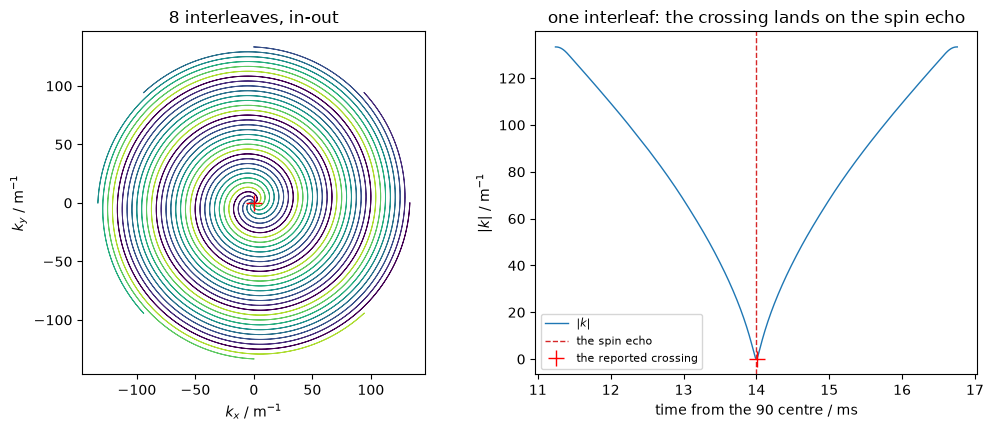

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(10.4, 4.4))
for s in range(SHOTS):
    axes[0].plot(k_adc[0, s], k_adc[1, s], lw=0.7, color=plt.cm.viridis(s / SHOTS))
axes[0].plot(0, 0, 'r+', ms=11)
axes[0].set(title=f'{SHOTS} interleaves, in-out', xlabel='$k_x$ / m$^{-1}$',
            ylabel='$k_y$ / m$^{-1}$', aspect='equal')

axes[1].plot((t_adc[0] - rf_90[0]) * 1e3, radius[0], lw=1.0, label='$|k|$')
axes[1].axvline(TE_S * 1e3, color='C3', lw=1.0, ls='--', label='the spin echo')
axes[1].plot((crossing[0] - rf_90[0]) * 1e3, radius[0, spiral.echo_sample(0)], 'r+', ms=12,
             label='the reported crossing')
axes[1].set(title='one interleaf: the crossing lands on the spin echo',
            xlabel='time from the 90 centre / ms', ylabel='$|k|$ / m$^{-1}$')
axes[1].legend(fontsize=8)
fig.tight_layout()

## 8. The files

In [12]:
for name, tree, echo_s in (('se_spiral_2d', scan, float(measured_te.mean())),
                           ('se_spiral_2d_gre_control', control, float(gre_te.mean()))):
    written = sc.compile(tree, opts, name=name, definitions={
        'FOV': [FOV_MM / 1e3, FOV_MM / 1e3, THICKNESS_MM / 1e3],
        'TE': echo_s, 'TR': TR_S,
    })
    written.write(str(SEQ_DIR / f'{name}.seq'))
    print(f'{name:26s} {len(written.block_events):4d} blocks  '
          f'{written.duration()[0]:5.1f} s  -> seq/{name}.seq')

se_spiral_2d                 90 blocks   10.0 s  -> seq/se_spiral_2d.seq
se_spiral_2d_gre_control     70 blocks   10.0 s  -> seq/se_spiral_2d_gre_control.seq


/var/folders/16/qs6slfs1615_9cf889mc198c0000gn/T/ipykernel_61050/1090437786.py:3: SeqCraftWarning: 8 blocks over the vector-norm limit (legal on real amplifiers): se_spiral_2d.se_spiral_tr.SpiralReadout (slew 139% at 3012.280 ms), se_spiral_2d.se_spiral_tr.SpiralReadout (slew 139% at 3018.120 ms), se_spiral_2d.se_spiral_tr.SpiralReadout (slew 139% at 5012.280 ms), se_spiral_2d.se_spiral_tr.SpiralReadout (slew 139% at 5018.120 ms), se_spiral_2d.se_spiral_tr.SpiralReadout (slew 139% at 7012.280 ms) (+3 more sites)
  written = sc.compile(tree, opts, name=name, definitions={
/var/folders/16/qs6slfs1615_9cf889mc198c0000gn/T/ipykernel_61050/1090437786.py:3: SeqCraftWarning: 8 blocks over the vector-norm limit (legal on real amplifiers): se_spiral_2d_gre_control.se_spiral_tr.SpiralReadout (slew 139% at 3012.280 ms), se_spiral_2d_gre_control.se_spiral_tr.SpiralReadout (slew 139% at 3018.120 ms), se_spiral_2d_gre_control.se_spiral_tr.SpiralReadout (slew 139% at 5012.280 ms), se_spiral_2d_gre_co

## Summary

| | |
|---|---|
| **the spin echo and the origin crossing are different facts** | one is fixed by the two RF centres, the other by the trajectory, and only the composition can make them coincide |
| **the join is exact to one gradient raster** | 2.0 µs residual against a 14 ms echo time, identical across all eight interleaves to nanoseconds — and the residual is quantisation, not error |
| **`k` at the echo is 0.02 Δk** | measured with pypulseq's own refocusing conjugation applied, so it is a statement about magnetisation and not about this notebook's arithmetic |
| **three wrong placements all compile** | 302 µs and 6.7 Δk for measuring from the arm rather than the block, 3.1 ms and 32 Δk for starting the readout at the echo. Neither is illegal, and neither shows up in a trajectory plot |
| **"the echo is in the middle" is right once in four** | correct for `'in-out'`, wrong for `'out'` and `'in'`, and worst for `'out-in'`, whose midpoint is at maximum `\|k\|` between its two crossings |
| **the placement is the composition** | three lines of arithmetic and an angle list, written where a caller can change them |

[`02_simulate_and_reconstruct.ipynb`](02_simulate_and_reconstruct.ipynb) simulates both files and
asks what the refocusing pulse actually bought: the trajectory crossing is not a spin echo, and
the difference between them is visible as $T_2$ against $T_2^*$.